# 😴 Sleep Disorder Risk: EDA & Multi-Class Classification with XGBoost

Sleep disorders affect a huge chunk of the population and are strongly tied to lifestyle, occupation, and mental health. In this notebook, I explore the **Sleep Health and Daily Performance Dataset** to understand what drives sleep disorder risk, then build an **XGBoost classifier** to predict risk level (Healthy → Mild → Moderate → Severe).

**What's inside:**
- 🔍 Exploratory Data Analysis (distributions, risk by age/gender/occupation)
- 🧪 Feature engineering & encoding
- 🌲 XGBoost multi-class classification
- 📊 Feature importance analysis — what actually predicts sleep disorder risk

If this notebook helps you or you find the analysis interesting, an **upvote** would mean a lot 🙏 — it helps others find it too. Feedback and suggestions are always welcome in the comments!

In [1]:
import os
import numpy as np
import pandas as pd

## 📥 1. Loading & Understanding the Data

Let's load the dataset and take a first look at its structure, types, and summary statistics.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv")

In [3]:
df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [6]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,0.596800,63.539620,0.450710,7496.859740,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,1.059161,44.550502,0.497567,3460.423881,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,500.000000,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,0.000000,30.000000,0.000000,5045.000000,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,0.000000,51.000000,0.000000,7442.000000,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,1.000000,84.000000,1.000000,9887.000000,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,6.000000,180.000000,1.000000,20000.000000,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [7]:
df.describe(include= "object")

,gender,occupation,country,chronotype,mental_health_condition,season,day_type,sleep_disorder_risk
count,100000,100000,100000,100000,100000,100000,100000,100000
unique,3,12,15,3,4,4,2,4
top,Female,Student,USA,Neutral,Healthy,Summer,Weekday,Healthy
freq,50203,14851,20050,45396,69993,25121,71428,54156


In [8]:
unique_val = {}

object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    unique_val[col] = df[col].unique().tolist()
print(unique_val)

{'gender': ['Female', 'Male', 'Other'], 'occupation': ['Driver', 'Software Engineer', 'Nurse', 'Student', 'Lawyer', 'Freelancer', 'Manager', 'Doctor', 'Homemaker', 'Teacher', 'Retired', 'Sales'], 'country': ['Japan', 'USA', 'India', 'Spain', 'Brazil', 'Netherlands', 'UK', 'Germany', 'South Korea', 'Australia', 'Canada', 'Italy', 'France', 'Sweden', 'Mexico'], 'chronotype': ['Morning', 'Neutral', 'Evening'], 'mental_health_condition': ['Healthy', 'Both', 'Depression', 'Anxiety'], 'season': ['Autumn', 'Winter', 'Spring', 'Summer'], 'day_type': ['Weekday', 'Weekend'], 'sleep_disorder_risk': ['Healthy', 'Severe', 'Mild', 'Moderate']}


## 📊 2. Exploratory Data Analysis

Time to visualize how sleep disorder risk relates to age, gender, occupation, and behavioral factors like caffeine intake and sleep latency.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sns.set_theme(style= "whitegrid")
plt.rcParams.update({"font.size": 10, "axes.labelsize": 12, "axes.titlesize": 14})

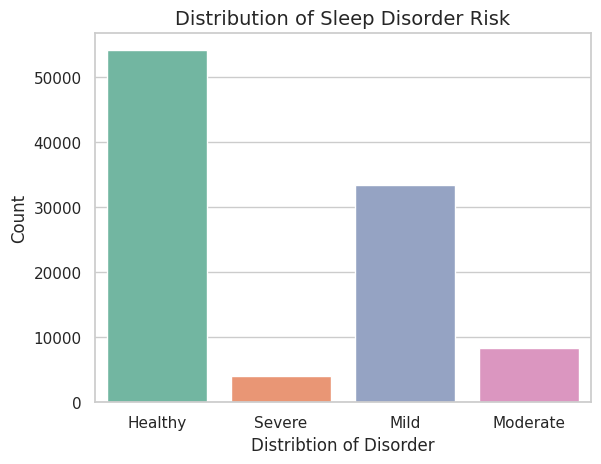

In [11]:
sns.countplot(
    data=df,
    x="sleep_disorder_risk",
    hue="sleep_disorder_risk",
    palette="Set2",
    legend=False,
)
plt.title("Distribution of Sleep Disorder Risk")
plt.xlabel("Distribtion of Disorder")
plt.ylabel("Count")
plt.show()

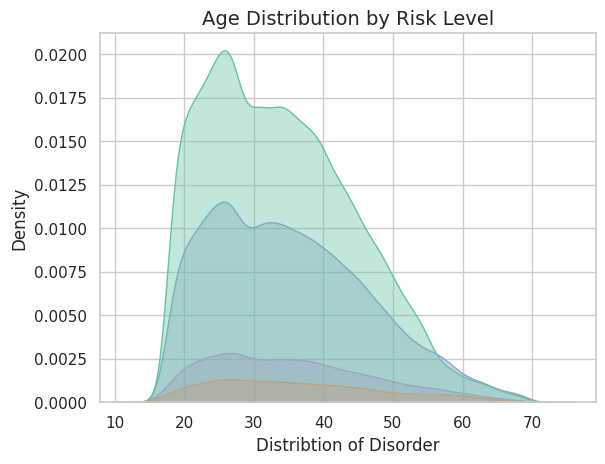

In [12]:
sns.kdeplot(
    data=df,
    x="age",
    hue="sleep_disorder_risk",
    palette="Set2",
    alpha=0.4,
    fill = True,
    legend=False,
)
plt.title("Age Distribution by Risk Level")
plt.xlabel("Distribtion of Disorder")
plt.ylabel("Density")
plt.show()

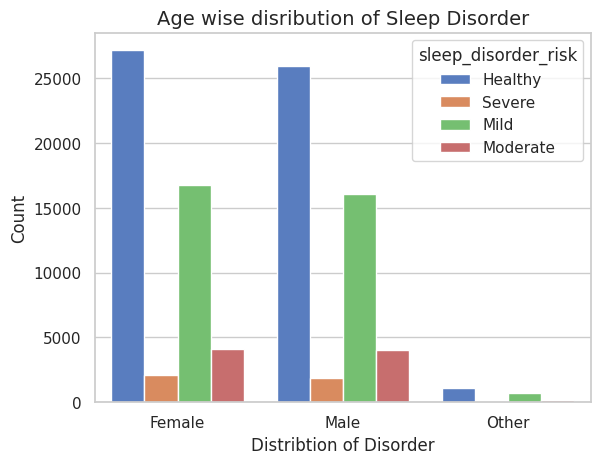

In [13]:
sns.countplot(
    data=df,
    x="gender",
    hue="sleep_disorder_risk",
    palette="muted",
)

plt.title("Age wise disribution of Sleep Disorder")
plt.xlabel("Distribtion of Disorder")
plt.ylabel("Count")
plt.show()

Text(0.5, 1.0, 'Sleep Latency vs Risk Level')

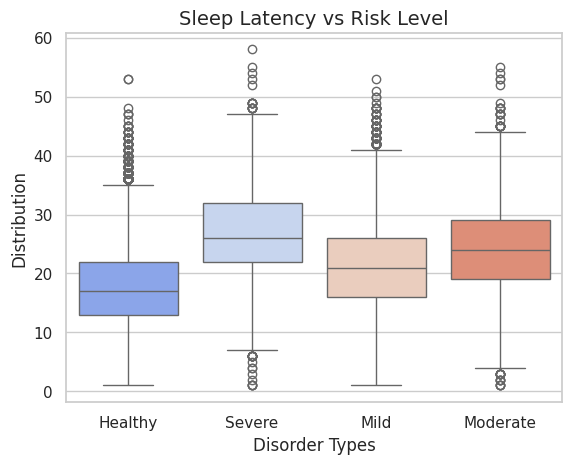

In [14]:
sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="sleep_latency_mins",
    hue="sleep_disorder_risk",
    palette="coolwarm",
    legend=False,
)

plt.xlabel("Disorder Types")
plt.ylabel("Distribution")
plt.title("Sleep Latency vs Risk Level")

Text(0.5, 1.0, 'Sleep Latency vs Risk Level')

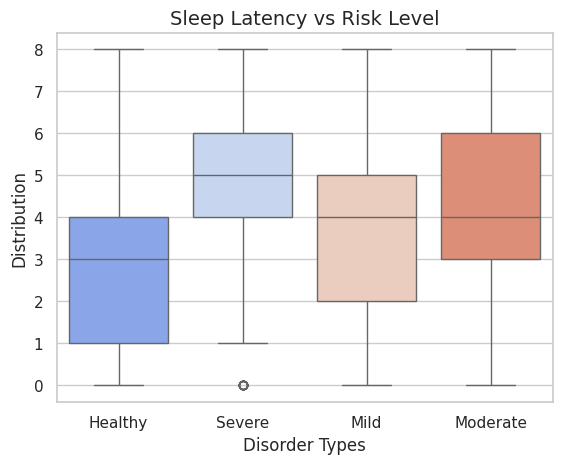

In [15]:
sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="wake_episodes_per_night",
    hue="sleep_disorder_risk",
    palette="coolwarm",
    legend=False,
)

plt.xlabel("Disorder Types")
plt.ylabel("Distribution")
plt.title("Sleep Latency vs Risk Level")

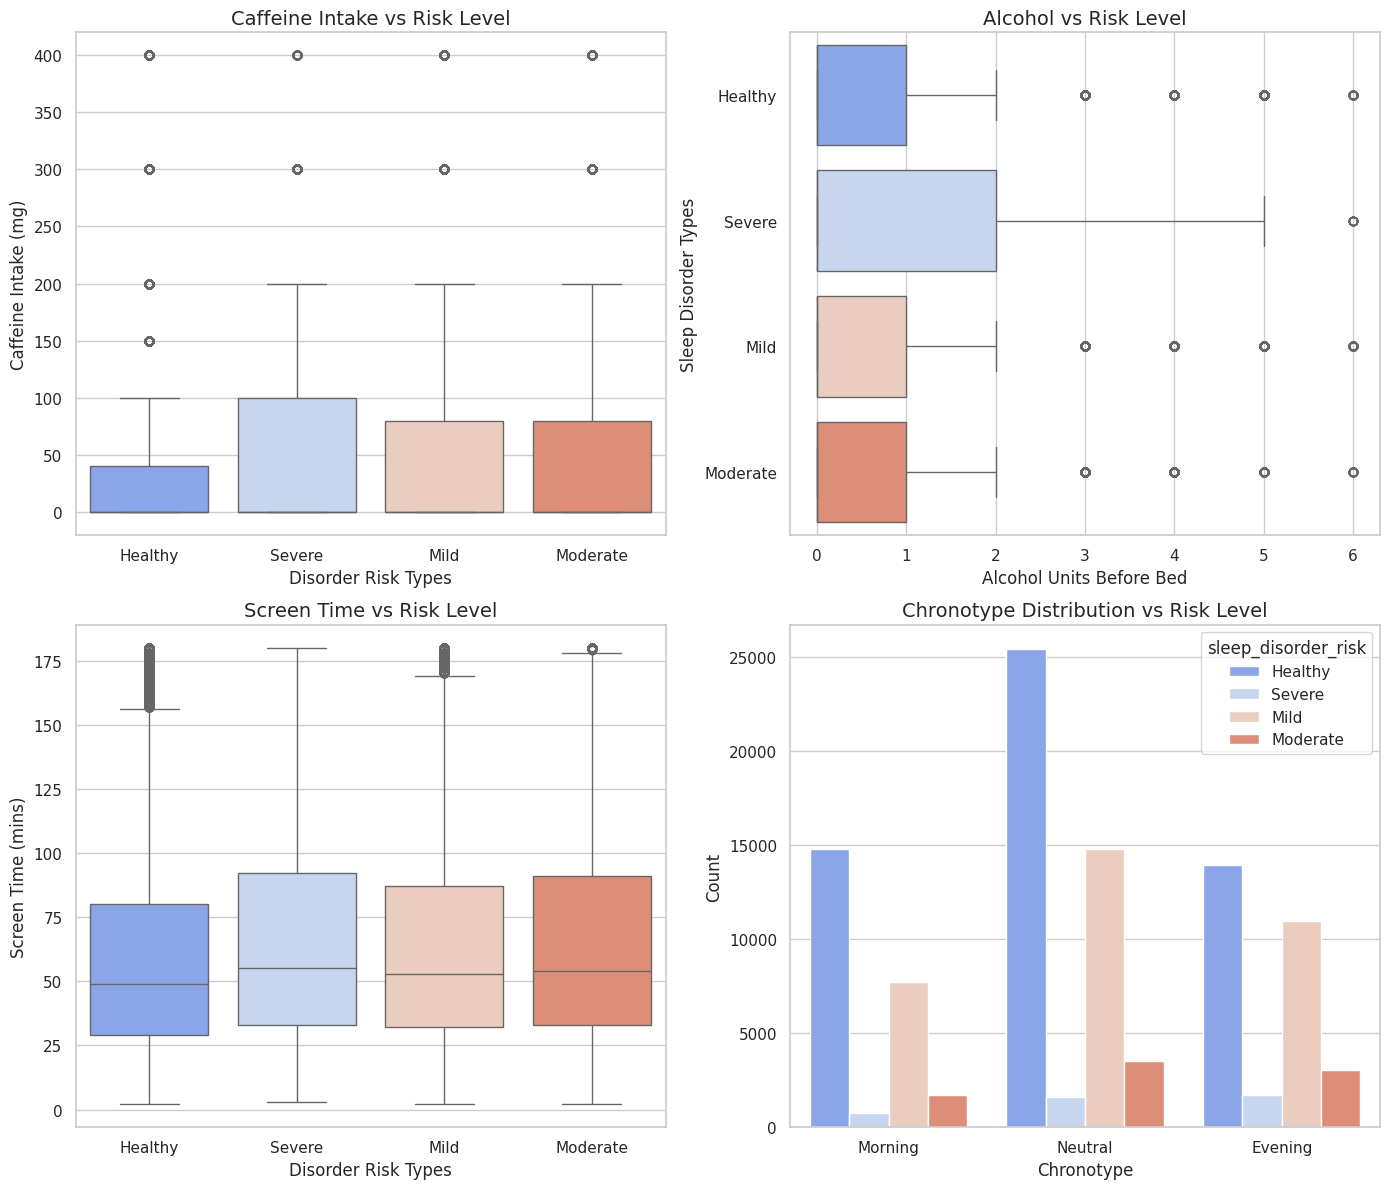

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax = axes.flatten()

sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="caffeine_mg_before_bed",
    hue="sleep_disorder_risk",
    palette="coolwarm",
    ax=ax[0],
    legend=False,
)
ax[0].set_xlabel("Disorder Risk Types")
ax[0].set_ylabel("Caffeine Intake (mg)")
ax[0].set_title("Caffeine Intake vs Risk Level")

sns.boxplot(
    data=df,
    x="alcohol_units_before_bed",
    y="sleep_disorder_risk",
    hue="sleep_disorder_risk",
    palette="coolwarm",
    ax=ax[1],
)
ax[1].set_xlabel("Alcohol Units Before Bed")
ax[1].set_ylabel("Sleep Disorder Types")
ax[1].set_title("Alcohol vs Risk Level")

sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="screen_time_before_bed_mins",
    hue="sleep_disorder_risk",
    palette="coolwarm",
    ax=ax[2],
    legend=False,
)
ax[2].set_xlabel("Disorder Risk Types")
ax[2].set_ylabel("Screen Time (mins)")
ax[2].set_title("Screen Time vs Risk Level")

sns.countplot(
    data=df,
    x="chronotype",
    hue="sleep_disorder_risk",
    palette="coolwarm",
    ax=ax[3],
)
ax[3].set_xlabel("Chronotype")
ax[3].set_ylabel("Count")
ax[3].set_title("Chronotype Distribution vs Risk Level")

plt.tight_layout()
plt.show()

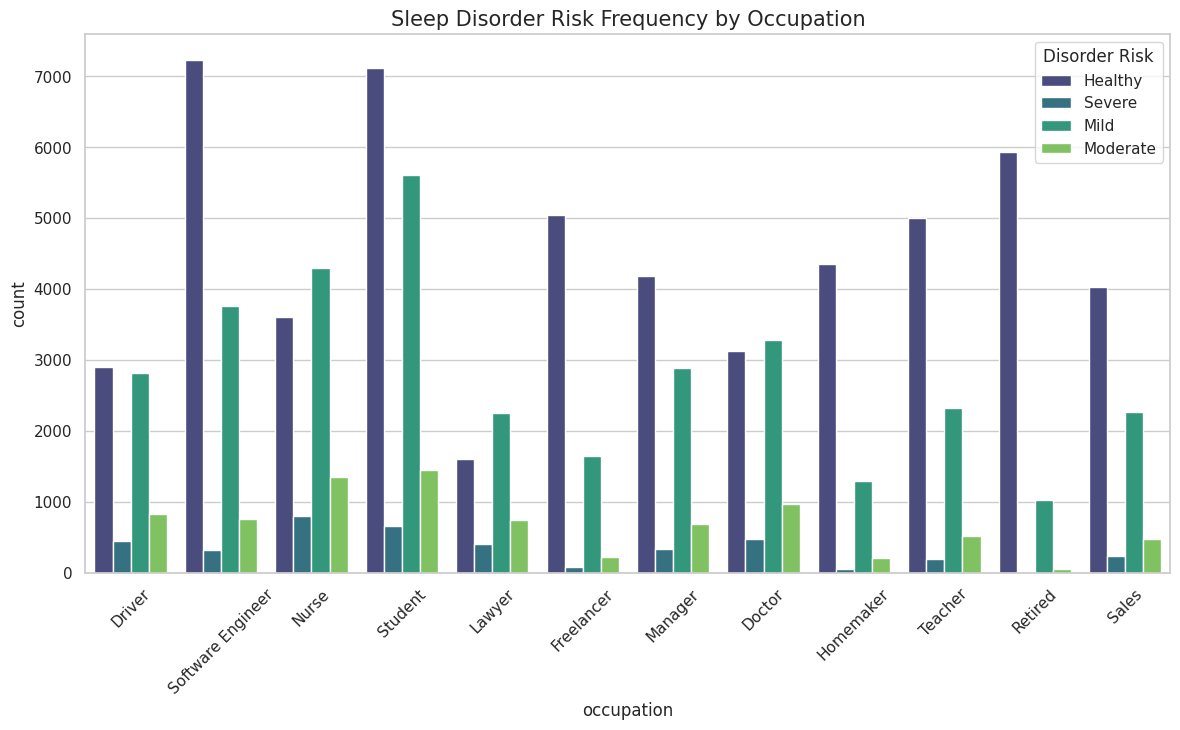

In [17]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='occupation', hue='sleep_disorder_risk', palette='viridis')
plt.title('Sleep Disorder Risk Frequency by Occupation', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Disorder Risk')
plt.show()

## 🤖 3. Feature Engineering & Model Building

With the EDA insights in hand, let's prepare the data (encoding categoricals, filtering low-variance features) and train an **XGBoost classifier** to predict sleep disorder risk level.

In [18]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [19]:
target_mapping = {"Healthy": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
df["target_encoded"] = df["sleep_disorder_risk"].map(target_mapping)

In [20]:
categorical_cols = ["gender", "occupation", "country", "chronotype", 
                    "mental_health_condition", "season", "day_type"]

X_raw = df.drop(columns=["person_id", "sleep_disorder_risk", "target_encoded"] + categorical_cols)
X_categorical = pd.get_dummies(df[categorical_cols], drop_first=True)
X = pd.concat([X_raw, X_categorical], axis=1)

In [21]:
var_selector = VarianceThreshold(threshold=0.1)
var_selector.fit(X)

VarianceThreshold(threshold=0.1)

In [22]:
X_final = X.iloc[:, var_selector.get_support()]
Y = df["target_encoded"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, Y, test_size=0.2, random_state=42, stratify=Y
)

In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

### ✅ Model Evaluation

Classification report across all four risk classes (Healthy, Mild, Moderate, Severe).

In [25]:
print("\n=== Model Evaluation Report ===")
print(classification_report(y_test, y_pred, target_names=list(target_mapping.keys())))


=== Model Evaluation Report ===
              precision    recall  f1-score   support

     Healthy       0.97      0.98      0.97     10831
        Mild       0.89      0.91      0.90      6696
    Moderate       0.68      0.61      0.65      1660
      Severe       0.83      0.72      0.77       813

    accuracy                           0.92     20000
   macro avg       0.84      0.81      0.82     20000
weighted avg       0.91      0.92      0.91     20000



## 🧠 4. What Drives Sleep Disorder Risk? (Feature Importance)

Beyond just predicting risk, it's worth understanding *why* — which features the model relies on most heavily gives us actionable, public-health-relevant insight.

In [26]:
importances  = xgb_model.feature_importances_
feature_names = X_train.columns

In [27]:
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


In [28]:
print(feat_imp_df.to_string(index=False))

                        Feature  Importance
            sleep_quality_score    0.236394
    cognitive_performance_score    0.140307
mental_health_condition_Healthy    0.130777
                            bmi    0.062901
             sleep_duration_hrs    0.056882
        wake_episodes_per_night    0.056715
             sleep_latency_mins    0.043700
                   stress_score    0.036400
                    felt_rested    0.029570
       alcohol_units_before_bed    0.023620
                   exercise_day    0.021612
         caffeine_mg_before_bed    0.017625
                            age    0.015462
                 rem_percentage    0.014992
               day_type_Weekend    0.012436
          deep_sleep_percentage    0.006186
             chronotype_Morning    0.005856
                 steps_that_day    0.005811
       room_temperature_celsius    0.005657
            work_hours_that_day    0.005641
                  season_Winter    0.005555
             occupation_Student 

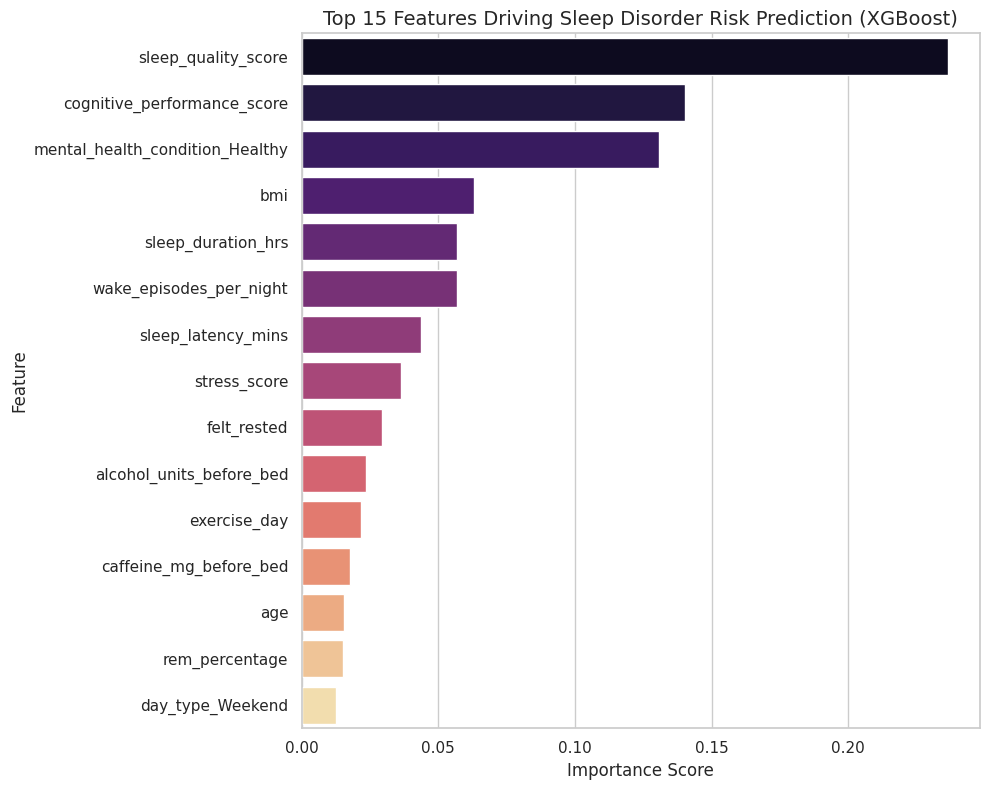

In [29]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', 
            data=feat_imp_df.head(15), palette='magma', legend=False)
plt.title('Top 15 Features Driving Sleep Disorder Risk Prediction (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

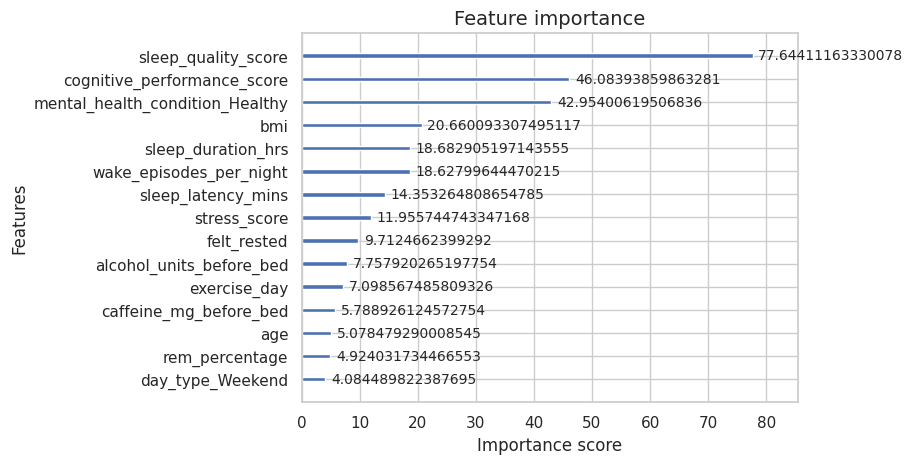

In [30]:
from xgboost import plot_importance
plot_importance(xgb_model, importance_type='gain', max_num_features=15)
plt.show()

## 🏁 Conclusion & Takeaways

- Sleep disorder risk shows clear patterns across age, occupation, caffeine intake, and sleep latency.
- XGBoost captured these patterns well, and the feature importance plot highlights the strongest behavioral/lifestyle predictors.
- These insights could inform simple, low-cost interventions (e.g., caffeine timing, occupation-specific sleep hygiene programs) for public health use cases.

**Next steps I'm considering:** hyperparameter tuning (Optuna), SHAP values for per-prediction explainability, and trying an ensemble with LightGBM.

---
💡 **If you found this useful, please consider upvoting** — it genuinely helps this notebook reach more people, and I'd love to hear your feedback or suggestions for improvement in the comments. Thanks for reading! 🙌